In [56]:
import numpy as np
import matplotlib.pyplot as plt
from core.greeks import delta
from core.dynamics import delta_adjusted, repo_sensitivity, delta_static_curve
from core.forward import repo_curve

In [57]:
S = 100
K = 100
T = 1
r = 0.05
q= 0.02
sigma = 0.2
rho_obs = 0.03

In [58]:
rho_range = np.linspace(0, 0.3, 200)

delta_static = np.array([delta(S, K, r, q, rho, T, sigma) for rho in rho_range])
delta_iso   = np.array([delta_adjusted(S, K, T, r, q, rho, rho_obs, sigma) for rho in rho_range])
delta_ref   = delta(S, K, r, q, rho_obs, T, sigma)

## Section 1 — Static vs Iso-Forward Delta

The blue curve shows what happens in the original project when the repo rate increases. The delta drops sharply because two things are happening at the same time. The repo is rising and the forward is falling. The option looks further out of the money not because of the repo itself but because the reference price for the underlying has moved down.

The red curve fixes the forward and only lets the repo vary. The drop in delta is much more gradual. This is the pure effect of the repo on the delta, isolated from any change in the forward.

The gap between the two curves is the bias that was present in the original analysis. When comparing delta at rho=0% versus rho=15% without fixing the forward, a large part of the difference comes from the forward moving, not from the repo itself. This approach consisting of isolating the forward gives a cleaner and more honest measure of how much the repo actually affects the hedge ratio.

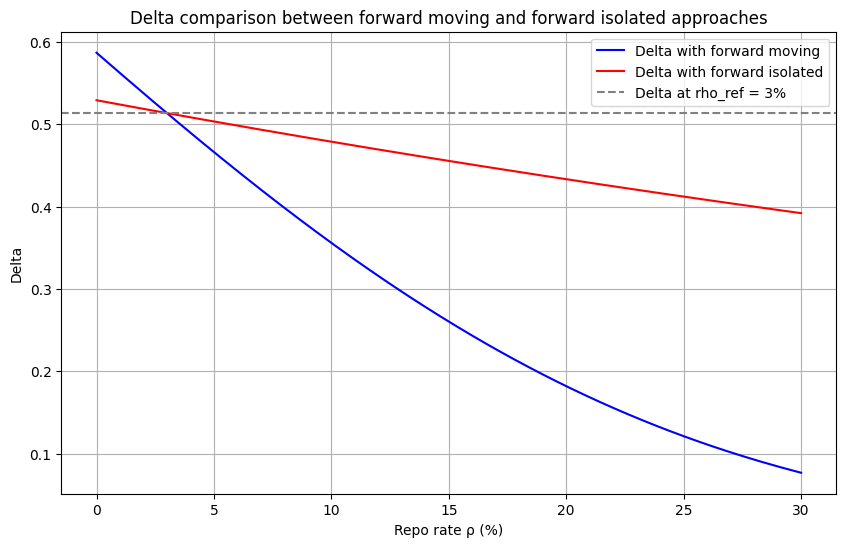

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(rho_range * 100, delta_static, label="Delta with forward moving", color="blue")
plt.plot(rho_range * 100, delta_iso, label="Delta with forward isolated", color="red")
plt.axhline(y=delta_ref, color='grey', linestyle='--', label=f"Delta at rho_ref = {rho_obs*100:.0f}%")
plt.xlabel("Repo rate ρ (%)")
plt.ylabel("Delta")
plt.title("Delta comparison between forward moving and forward isolated approaches")
plt.legend()
plt.grid(True)
plt.show()

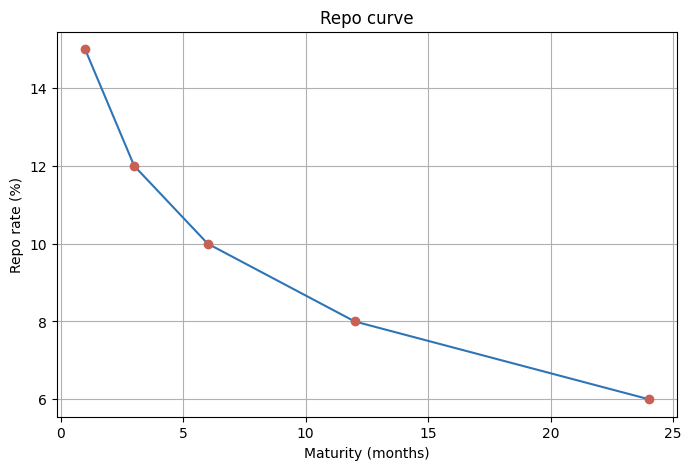

In [60]:
tenors = [0.083, 0.25, 0.5, 1.0, 2.0]
rates  = [0.15,  0.12, 0.10, 0.08, 0.06]

T_plot = np.linspace(0.083, 2.0, 200)
rho_plot = [repo_curve(t, tenors, rates) for t in T_plot]

plt.figure(figsize=(8, 5))
plt.plot([t * 12 for t in T_plot], [r * 100 for r in rho_plot], color="#2E75B6")
plt.scatter([t * 12 for t in tenors], [r * 100 for r in rates], 
            color="#C76155", zorder=5)
plt.xlabel("Maturity (months)")
plt.ylabel("Repo rate (%)")
plt.title("Repo curve")
plt.grid(True)
plt.show()

## Section 2 — Regression ρ = f(S)

The repo rate and the spot price are not independent. On a hard-to-borrow stock, when the price rises short sellers start losing money and begin covering their positions. That reduces the demand for borrow and the repo rate comes down. When the price falls, new short sellers enter the market, competition for borrow increases and the rate goes back up.

The regression captures this relationship empirically. Beta is negative at -0.005, meaning that for every 10 point rise in the spot the implied repo drops by roughly 4.96%. Across the full range of the simulation, from 80 to 140, that represents approximately 30 point compression in the borrow rate driven purely by the spot moving.

A delta hedge that ignores this relationship will systematically mis-hedge. The dynamic model accounts for this by updating the repo estimate every time the spot moves.

In [66]:
np.random.seed(42)


S_sim = np.linspace(80, 140, 100) + np.random.normal(0, 2, 100)
alpha_t = 0.70
beta_t = -0.005
rho_sim    = alpha_t + beta_t * S_sim + np.random.normal(0, 0.01, 100)
rho_sim    = np.maximum(rho_sim, 0.01)

alpha_est, beta_est = repo_sensitivity(S_sim, rho_sim)

rho_fitted = alpha_est + beta_est * S_sim


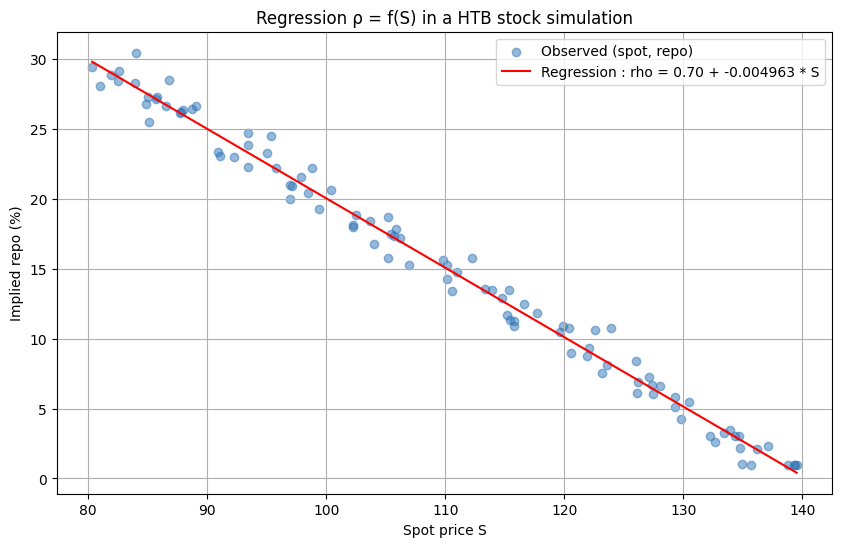

Alpha (intercept) : 0.6966
Beta  (slope)     : -0.004963
Interpretation    : with +10 points in spot, repo changes by -4.96%


In [67]:
plt.figure(figsize=(10, 6))
plt.scatter(S_sim, rho_sim * 100, alpha=0.5, color="#2E75B6", label="Observed (spot, repo)")
plt.plot(np.sort(S_sim), (alpha_est + beta_est * np.sort(S_sim)) * 100,
         color="red", label=f"Regression : rho = {alpha_est:.2f} + {beta_est:.6f} * S")
plt.xlabel("Spot price S")
plt.ylabel("Implied repo (%)")
plt.title("Regression ρ = f(S) in a HTB stock simulation")
plt.legend()
plt.grid(True)
plt.show()

print(f"Alpha (intercept) : {alpha_est:.4f}")
print(f"Beta  (slope)     : {beta_est:.6f}")
print(f"Interpretation    : with +10 points in spot, repo changes by {beta_est*10*100:.2f}%")

## Section 3 — Backtest P&L : Model 1 vs Model 2

Both models keep the forward price constant when the repo changes. The only difference between them is how the repo rate is estimated at each point in time.

Model 1 uses a static repo curve where the borrow rate depends only on maturity. It is fixed in time and does not react to market conditions. Model 2 uses a dynamic repo where the borrow rate is a function of the spot price, estimated from the regression in Section 2. When the spot moves, the repo moves with it.

The two P&L curves are close to each other because both models correctly remove the forward bias that was present in the original project. 

The gap between the two models becomes visible during periods of large spot moves. When the spot drops from 100 to 88, the dynamic repo rises by roughly 6 points relative to the static curve. Model 2 detects that borrowing is more expensive and adjusts the delta downward. Model 1 ignores this and maintains the same hedge ratio as before the move. Over the periods of sustained decline, Model 2 accumulates slightly less P&L error, visible as the red curve staying above the yellow one.

Model 2 is theoretically superior because it captures a real economic relationship. The repo and the spot are not independent on a hard-to-borrow stock. In practice the difference is modest on a calm path but becomes significant on names with a high beta or during stress periods like a short squeeze where the borrow rate can double in a matter of days.

In [138]:
np.random.seed(42)
N = 252
dt = 1/252
S0 = 100.0
K = 100.0
T_total = 1.0
r = 0.05
q = 0.02
sigma = 0.15
rho_obs = 0.10
notional = 10000

In [139]:
S_path = np.zeros(N)
S_path[0] = S0
for t in range(1, N):
    Z = np.random.normal()
    S_path[t] = S_path[t-1] * np.exp((r - q - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

pnl_model1 = [0.0]
pnl_model2 = [0.0]

for t in range(1, N):
    T_rem   = (N - t) / 252
    move    = S_path[t] - S_path[t-1]

    d_model1 = delta_static_curve(S_path[t-1], K, T_rem, r, q, sigma, tenors, rates)

    rho_dyn  = np.clip(alpha_est + beta_est * S_path[t-1], 0, None)
    rho_ref  = repo_curve(T_rem, tenors, rates)
    d_model2 = delta_adjusted(S_path[t-1], K, T_rem, r, q, rho_dyn, rho_ref, sigma)

    pnl_model1.append(pnl_model1[-1] + d_model1 * move * notional)
    pnl_model2.append(pnl_model2[-1] + d_model2 * move * notional)


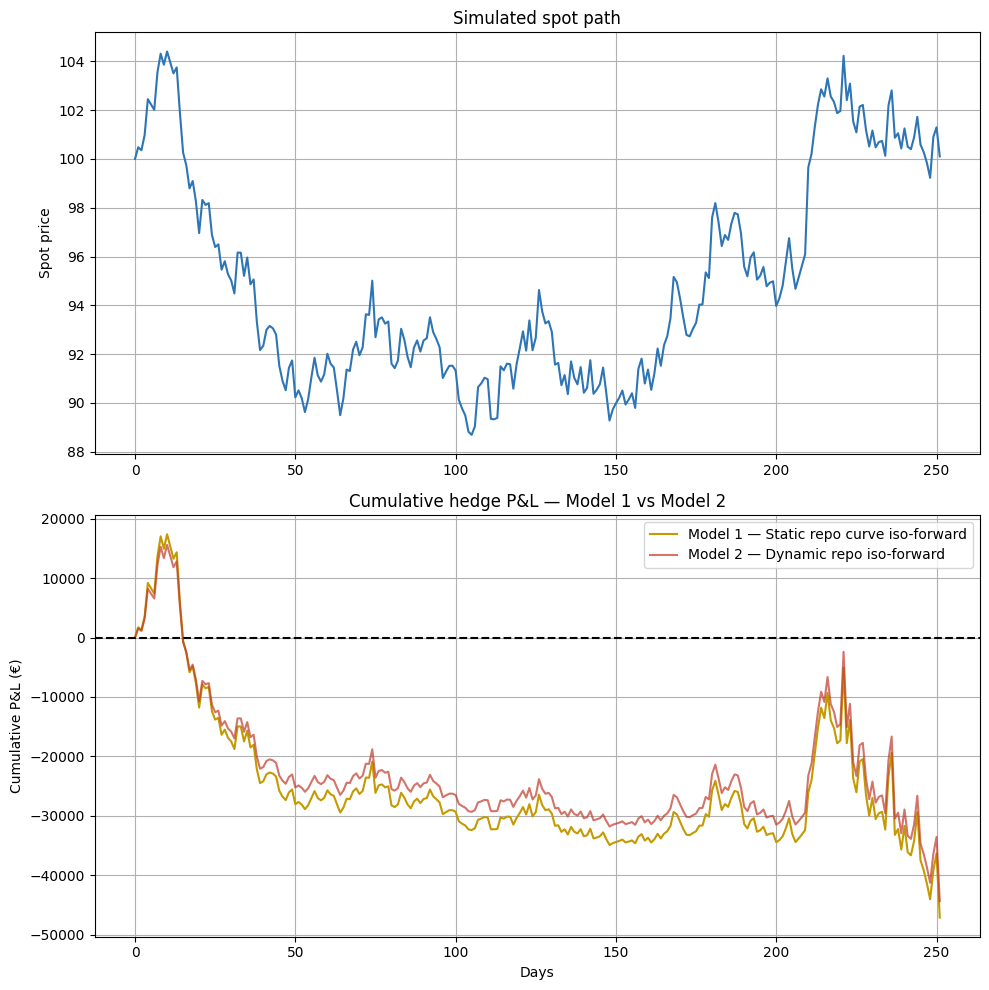

Final P&L Model 1 : -47102 €
Final P&L Model 2 : -44336 €
Difference        : 2766 €


In [141]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(S_path, color="#2E75B6")
ax1.set_title("Simulated spot path")
ax1.set_ylabel("Spot price")
ax1.grid(True)

ax2.plot(pnl_model1, label="Model 1 — Static repo curve iso-forward", color="#C49A00")
ax2.plot(pnl_model2, label="Model 2 — Dynamic repo iso-forward", color="#C0392B", alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--')
ax2.set_title("Cumulative hedge P&L — Model 1 vs Model 2")
ax2.set_xlabel("Days")
ax2.set_ylabel("Cumulative P&L (€)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Final P&L Model 1 : {pnl_model1[-1]:.0f} €")
print(f"Final P&L Model 2 : {pnl_model2[-1]:.0f} €")
print(f"Difference        : {abs(pnl_model1[-1] - pnl_model2[-1]):.0f} €")